# Loading Libraries

In [2]:
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.linear_model import Perceptron, SGDClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import train_test_split

# Importing Data

In [ ]:
sys.path.append(str(Path().resolve().parents[1]))
from dm_classif.config import PROCESSED_DATA_DIR

import pandas as pd

# Load the data
train_df = pd.read_csv(PROCESSED_DATA_DIR / "train_processed.csv")
test_df = pd.read_csv(PROCESSED_DATA_DIR / "test_processed.csv")

# Split Features and Target

In [5]:
X_train = train_df.drop(columns="Diabetes_binary")
y_train = train_df["Diabetes_binary"]

X_test = test_df.drop(columns="Diabetes_binary")
y_test = test_df["Diabetes_binary"]

# Function to evaluate the Model

In [6]:
def evaluate_model(model, X_train, y_train, X_test, y_test, name=''):
    # Train predictions
    train_preds = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, train_preds)
    train_recall = recall_score(y_train, train_preds, average='binary')  # or 'macro' for multi-class
    train_cf = confusion_matrix(y_train, train_preds, normalize='true')
    
    # Test predictions
    test_preds = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, test_preds)
    test_recall = recall_score(y_test, test_preds, average='binary')
    test_cf = confusion_matrix(y_test, test_preds, normalize='true')
    
    # Print accuracy and recall
    print(f"{name} Accuracy:")
    print(f"  Train: {train_accuracy * 100:.2f}%")
    print(f"  Test : {test_accuracy * 100:.2f}%")
    print(f"{name} Recall:")
    print(f"  Train: {train_recall * 100:.2f}%")
    print(f"  Test : {test_recall * 100:.2f}%")

    # Print classification report (includes recall too)
    print(f"\n{name} Classification Report (Test):")
    print(classification_report(y_test, test_preds))

    # Plot confusion matrices
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(train_cf, annot=True, ax=axs[0], cmap='Blues')
    axs[0].set_title(f"{name} - Train Confusion Matrix")
    axs[0].set_xlabel('Predicted')
    axs[0].set_ylabel('Actual')

    sns.heatmap(test_cf, annot=True, ax=axs[1], cmap='Greens')
    axs[1].set_title(f"{name} - Test Confusion Matrix")
    axs[1].set_xlabel('Predicted')
    axs[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

# SGDClassifier

SGD Classifier Accuracy:
  Train: 73.39%
  Test : 73.89%
SGD Classifier Recall:
  Train: 70.73%
  Test : 71.12%

SGD Classifier Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.72      0.77      0.74      6723
         1.0       0.76      0.71      0.74      7089

    accuracy                           0.74     13812
   macro avg       0.74      0.74      0.74     13812
weighted avg       0.74      0.74      0.74     13812



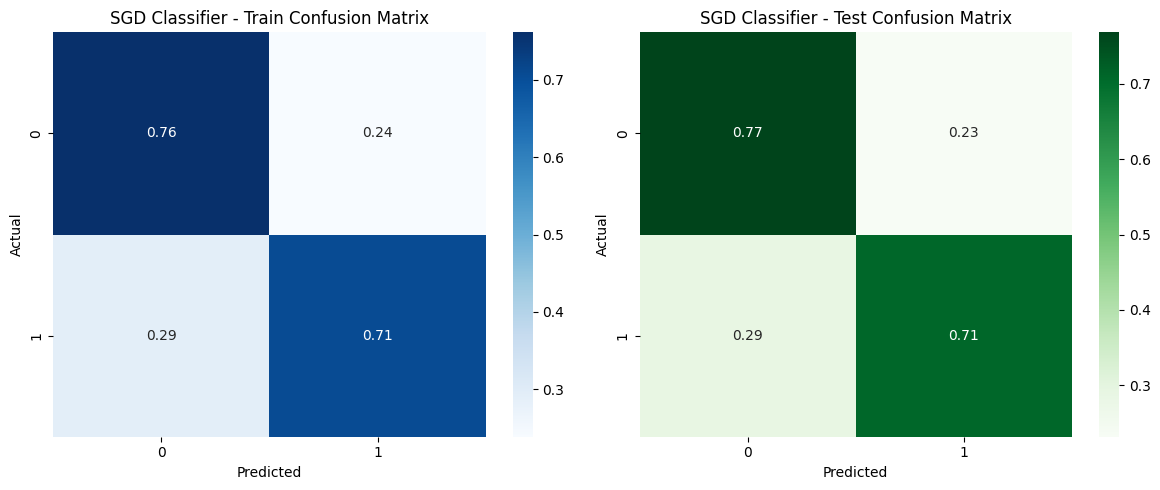

In [7]:
sgd = SGDClassifier(loss='log_loss', penalty='l2', max_iter=1000, random_state=42)
sgd.fit(X_train, y_train)
evaluate_model(sgd, X_train, y_train, X_test, y_test, name="SGD Classifier")

# SGDClassifier Tuned

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters for SGDClassifier:
{'alpha': 0.0001, 'eta0': 0.01, 'learning_rate': 'optimal', 'loss': 'modified_huber', 'max_iter': 1000, 'penalty': 'elasticnet'}
Tuned SGDClassifier Accuracy:
  Train: 73.62%
  Test : 74.46%
Tuned SGDClassifier Recall:
  Train: 72.26%
  Test : 72.70%

Tuned SGDClassifier Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.73      0.76      0.74      6723
         1.0       0.76      0.73      0.75      7089

    accuracy                           0.74     13812
   macro avg       0.75      0.75      0.74     13812
weighted avg       0.75      0.74      0.74     13812



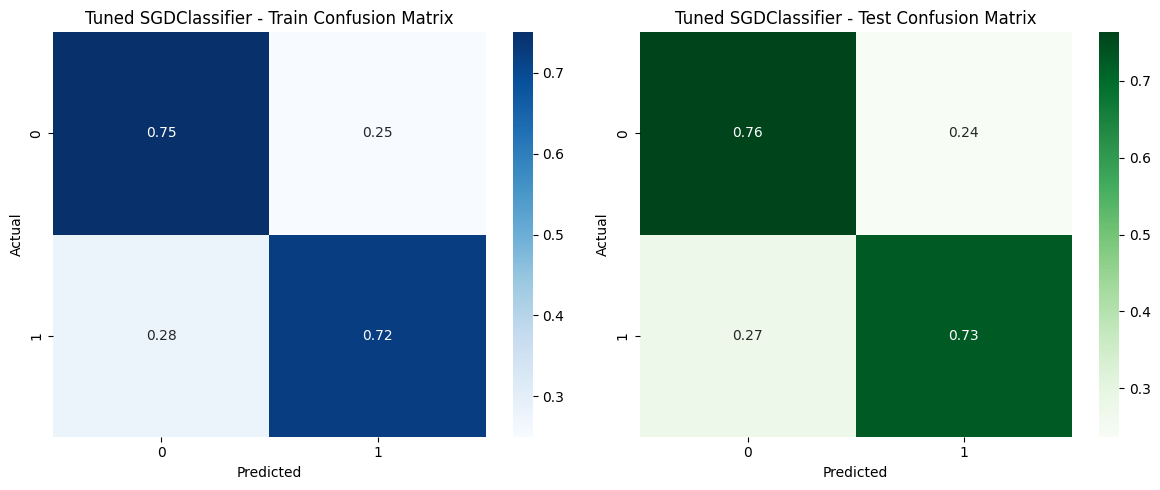

In [8]:
param_grid_sgd = {
    'loss': ['hinge', 'log_loss', 'modified_huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [0.0001, 0.001],
    'learning_rate': ['optimal', 'adaptive', 'invscaling'],
    'eta0': [0.01, 0.1],
    'max_iter': [1000],
}

sgd = SGDClassifier(random_state=42)

grid_sgd = GridSearchCV(sgd, param_grid_sgd, cv=3, scoring='recall', n_jobs=-1, verbose=1)
grid_sgd.fit(X_train, y_train)

print("Best Parameters for SGDClassifier:")
print(grid_sgd.best_params_)

evaluate_model(grid_sgd.best_estimator_, X_train, y_train, X_test, y_test, name="Tuned SGDClassifier")

# Perceptron

Perceptron Accuracy:
  Train: 69.08%
  Test : 69.83%
Perceptron Recall:
  Train: 75.12%
  Test : 75.53%

Perceptron Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.71      0.64      0.67      6723
         1.0       0.69      0.76      0.72      7089

    accuracy                           0.70     13812
   macro avg       0.70      0.70      0.70     13812
weighted avg       0.70      0.70      0.70     13812



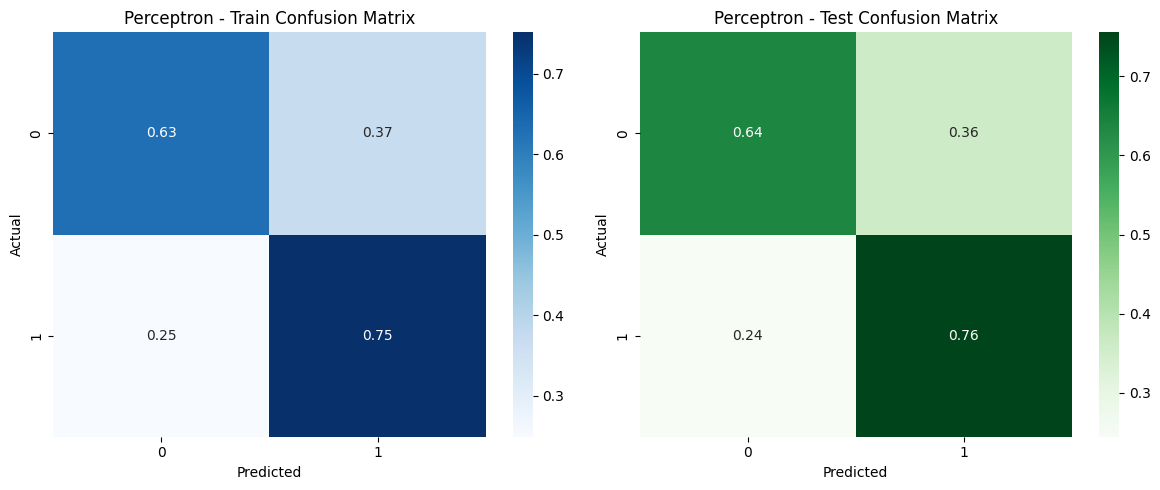

In [9]:
perceptron = Perceptron(max_iter=1000, random_state=42)
perceptron.fit(X_train, y_train)
evaluate_model(perceptron, X_train, y_train, X_test, y_test, name="Perceptron")

# Perceptron Tuned

Fitting 3 folds for each of 576 candidates, totalling 1728 fits
Best Parameters for Perceptron:
{'alpha': 0.0001, 'fit_intercept': False, 'l1_ratio': 0.15, 'max_iter': 1000, 'penalty': 'elasticnet', 'shuffle': True}
Tuned Perceptron Accuracy:
  Train: 64.51%
  Test : 65.23%
Tuned Perceptron Recall:
  Train: 91.44%
  Test : 91.78%

Tuned Perceptron Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.81      0.37      0.51      6723
         1.0       0.61      0.92      0.73      7089

    accuracy                           0.65     13812
   macro avg       0.71      0.65      0.62     13812
weighted avg       0.71      0.65      0.62     13812



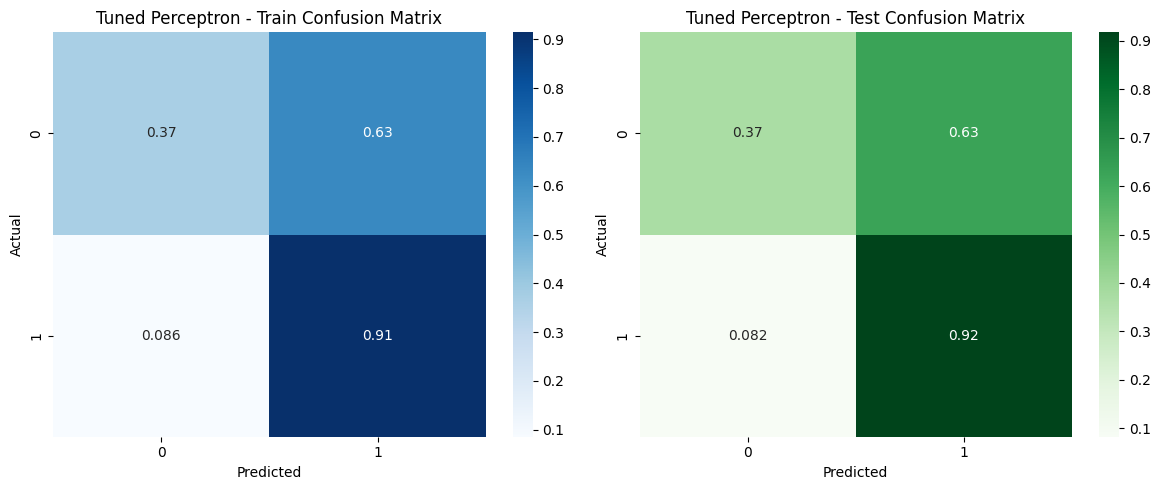

In [15]:
param_grid_perceptron = {
    'penalty': ['l2', 'l1', None, 'elasticnet'],
    'l1_ratio':[0,0.15,0.25,0.5,0.75,1],
    'alpha': [0.0001, 0.001, 0.01],
    'fit_intercept': [True, False],
    'max_iter': [1000, 2000],
    'shuffle': [True, False]
}

perceptron = Perceptron(random_state=42)

grid_perceptron = GridSearchCV(perceptron, param_grid_perceptron, cv=3, scoring='recall', n_jobs=-1, verbose=1)
grid_perceptron.fit(X_train, y_train)

print("Best Parameters for Perceptron:")
print(grid_perceptron.best_params_)

evaluate_model(grid_perceptron.best_estimator_, X_train, y_train, X_test, y_test, name="Tuned Perceptron")

# Linear SVC

Linear SVM Accuracy:
  Train: 74.03%
  Test : 74.97%
Linear SVM Recall:
  Train: 77.19%
  Test : 77.57%

Linear SVM Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.75      0.72      0.74      6723
         1.0       0.75      0.78      0.76      7089

    accuracy                           0.75     13812
   macro avg       0.75      0.75      0.75     13812
weighted avg       0.75      0.75      0.75     13812



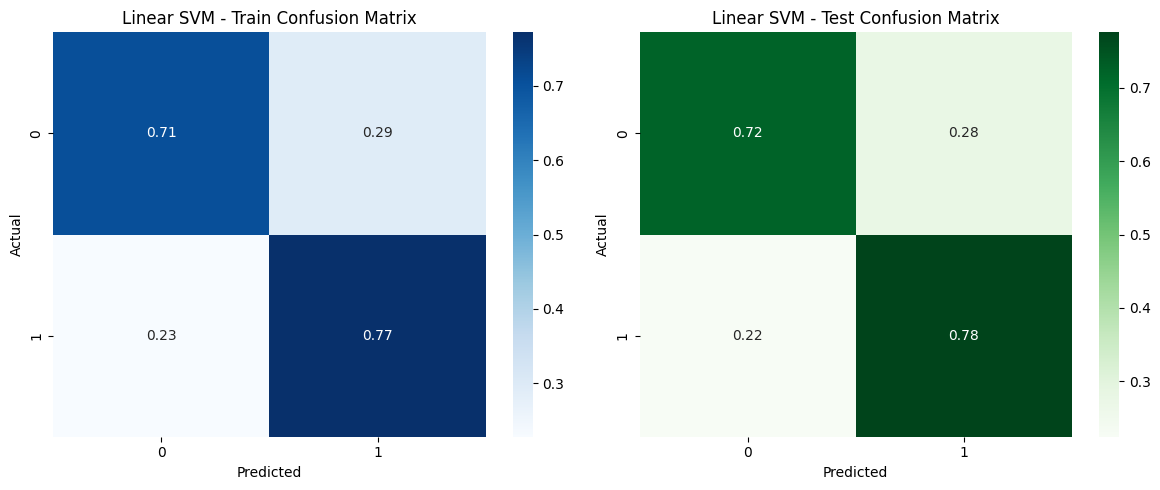

In [11]:
linear_svm = LinearSVC(max_iter=10000, random_state=42)
linear_svm.fit(X_train, y_train)

evaluate_model(linear_svm, X_train, y_train, X_test, y_test, name='Linear SVM')

# Linear SVC Tuned

Fitting 2 folds for each of 48 candidates, totalling 96 fits
Best Parameters for LinearSVC: {'C': 0.01, 'loss': 'squared_hinge', 'max_iter': 15000, 'penalty': 'l1', 'tol': 0.01}
Tuned LinearSVC Accuracy:
  Train: 73.95%
  Test : 74.97%
Tuned LinearSVC Recall:
  Train: 77.15%
  Test : 77.56%

Tuned LinearSVC Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.75      0.72      0.74      6723
         1.0       0.75      0.78      0.76      7089

    accuracy                           0.75     13812
   macro avg       0.75      0.75      0.75     13812
weighted avg       0.75      0.75      0.75     13812



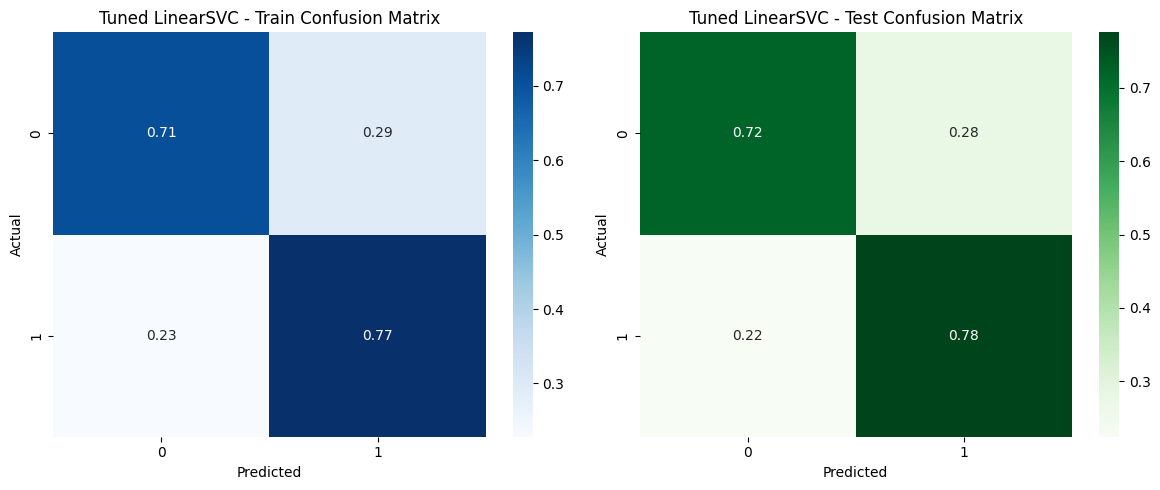

In [12]:
param_grid_lsvc = {
    'C': [0.01, 0.1, 1, 10],           
    'penalty': ['l1','l2'],                
    'loss': ['squared_hinge'],
    'tol': [1e-4, 1e-3, 1e-2],
    'max_iter': [15000, 20000]         
}

lsvc = LinearSVC(random_state=42)

grid_lsvc = GridSearchCV(
    estimator=lsvc,
    param_grid=param_grid_lsvc,
    cv=2,
    scoring='recall',
    n_jobs=3,
    verbose=1
)

grid_lsvc.fit(X_train, y_train)
print("Best Parameters for LinearSVC:", grid_lsvc.best_params_)
evaluate_model(grid_lsvc.best_estimator_, X_train, y_train, X_test, y_test, name="Tuned LinearSVC")

# Evaluation

| Models | Training Recall | Test Recall|
|--------|-------------------|--------------|
|SGDClassifier|70.73%|71.12%|
|SGDClassifier (Tuned)|72.26%|72.70%|
|Perceptron|75.12%|75.13%|
|Perceptron (Tuned)|91.44%|91.78%|
|LinearSVC|77.19%|77.57%|
|LinearSVC (Tuned)|77.15%|77.56%|